# NECIL×Machine Unlearningモデルが忘却クラスをどの程度再構成できるかを確認するノートブック

## 必要なライブラリのインポート

In [1]:
import os
import sys
import numpy as np
import json
from utils import factory

import torch
import torch.nn as nn
import torch.nn.functional as F

import models

## 学習済みモデルのcheckpointまでのパスを設定

### CIFAR100

In [2]:
# ベース部分のパス
ckpt_path = "/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint"

# cifar100のbaseline用パス
base_cifar100_path = "baseline/cifar100"

# baseline
method = "baseline"
baseline_path = os.path.join(ckpt_path, method, base_cifar100_path, "50/5/10_10_0_0_0")

# baseline_mu
method = "baseline_mu"
baseline_mu_path = os.path.join(ckpt_path, method, base_cifar100_path, "50/5/10_10_0_0_1.0")
# print("baseline_mu_path: ", baseline_mu_path)

# prl2
method = "prl2"
prl_path = os.path.join(ckpt_path, method, base_cifar100_path, "50/5/10_10_0.1_2_1.0")
# print("prl_path: ", prl_path)

# prl_mu
method = "prl-mu"
prl_mu_path = os.path.join(ckpt_path, method, base_cifar100_path, "50/5/10_10_0.1_2_1.0")
# print("prl_mu_path: ", prl_mu_path)

### tiny imagenet

In [108]:
# ベース部分のパス
ckpt_path = "/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL/checkpoint"

# tiny-imagenetのbaseline用パス
base_cifar100_path = "baseline/tiny200"

# baseline
method = "baseline"
baseline_path = os.path.join(ckpt_path, method, base_cifar100_path, "100/10/15_15_0.1_1_1")

## 基本的な情報の設定（適宜変更）

In [32]:
# プロジェクト root を sys.path に追加
project_root = "/home/kouyou/ContinualLearning/repexp/NeurIPS2024-PRL"
sys.path.append(project_root)


# --- 1) PRL_MU の設定を読む ---
with open(os.path.join(project_root, "exps", "BASELINE", "cifar.json")) as f:
    args = json.load(f)

args["device"] = ["0"]          # 必要に応じて
args["model_name"] = "prl-mu"   # 念のため明示


# --- 2) learner とネットワークの作成 ---
learner = factory.get_model(args["model_name"], args)
net = learner._network


# --- 3) checkpoint の読み込み ---
ckpt_dir = baseline_path                           # さっきのノートで定義したものを使う
ckpt_file = os.path.join(ckpt_dir, "phase0.pkl")  # 実際のファイル名に合わせて変更

ckpt = torch.load(ckpt_file, map_location="cuda:0")
state_dict = ckpt["model_state_dict"]
print(state_dict.keys())

# ここがポイント：fc の出力次元を checkpoint から取得
num_outputs = state_dict["fc.weight"].shape[0]
print("num_outputs: ", num_outputs)

# 先に fc をその次元で作っておく
net.update_fc(num_outputs)

# そのあとに state_dict を読み込む
net.load_state_dict(state_dict)

net.cuda().eval()

# 忘却クラスや class_order をノート側で使うなら:
forget_classes = ckpt.get("forget_classes", None)
class_order = ckpt.get("_class_order", None)

odict_keys(['convnet.conv1.0.weight', 'convnet.conv1.1.weight', 'convnet.conv1.1.bias', 'convnet.conv1.1.running_mean', 'convnet.conv1.1.running_var', 'convnet.conv1.1.num_batches_tracked', 'convnet.layer1.0.conv1.weight', 'convnet.layer1.0.bn1.weight', 'convnet.layer1.0.bn1.bias', 'convnet.layer1.0.bn1.running_mean', 'convnet.layer1.0.bn1.running_var', 'convnet.layer1.0.bn1.num_batches_tracked', 'convnet.layer1.0.conv2.weight', 'convnet.layer1.0.bn2.weight', 'convnet.layer1.0.bn2.bias', 'convnet.layer1.0.bn2.running_mean', 'convnet.layer1.0.bn2.running_var', 'convnet.layer1.0.bn2.num_batches_tracked', 'convnet.layer1.1.conv1.weight', 'convnet.layer1.1.bn1.weight', 'convnet.layer1.1.bn1.bias', 'convnet.layer1.1.bn1.running_mean', 'convnet.layer1.1.bn1.running_var', 'convnet.layer1.1.bn1.num_batches_tracked', 'convnet.layer1.1.conv2.weight', 'convnet.layer1.1.bn2.weight', 'convnet.layer1.1.bn2.bias', 'convnet.layer1.1.bn2.running_mean', 'convnet.layer1.1.bn2.running_var', 'convnet.layer

<ipython-input-32-d9fd0c8153e0>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_file, map_location="cuda:0")


## 公式実装に従った DeepInversion

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import List, Optional

In [5]:
class DeepInversionFeatureHook:
    """
    DeepInversion 公式実装と同じ思想の BN feature hook.
    - running_mean / running_var と 現在の batch の mean / var の L2 差を r_feature に保存
    - first_bn_multiplier を使って最初の BN だけ重くすることもできる
    """

    def __init__(self, module: nn.BatchNorm2d, scale: float=1.0):

        self.module = module
        self.scale = scale
        self.r_feature = torch.tensor(0.0, device=module.weight.device)
        self.hook = module.register_forward_hook(self.hook_fn)
    

    def hook_fn(self, module, inp, out):
        x = inp[0]  # (B, C, H, W)
        n_ch = x.shape[1]

        mean = x.mean(dim=[0, 2, 3])
        var = x.permute(1, 0, 2, 3).contiguous().view(n_ch, -1).var(dim=1, unbiased=False)

        r_mean = module.running_mean
        r_var = module.running_var

        diff_mean = (r_mean - mean)
        diff_var  = (r_var  - var)

        # L2 norm + スケール
        self.r_feature = self.scale * (
            torch.norm(diff_mean, p=2) + torch.norm(diff_var, p=2)
        )

    def close(self):
        self.hook.remove()




In [ ]:
def tv_loss(x: torch.Tensor) -> torch.Tensor:
    """
    DeepInversion の RTV に対応する TV loss.
    4 方向(横/縦/対角2方向)の差分の L2 を足し合わせる。
    x: (B, C, H, W) in [0,1]
    """
    diff_h  = x[:, :, :, 1:]   - x[:, :, :, :-1]
    diff_v  = x[:, :, 1:, :]   - x[:, :, :-1, :]
    diff_dr = x[:, :, 1:, 1:]  - x[:, :, :-1, :-1]
    diff_dl = x[:, :, 1:, :-1] - x[:, :, :-1, 1:]

    tv = (
        torch.norm(diff_h,  p=2) +
        torch.norm(diff_v,  p=2) +
        torch.norm(diff_dr, p=2) +
        torch.norm(diff_dl, p=2)
    )
    return tv 


def js_divergence(p_logits: torch.Tensor,
                  q_logits: torch.Tensor,
                  temp: float = 1.0) -> torch.Tensor:
    """
    Adaptive DeepInversion (ADI) 用の JS divergence.
    """
    p = F.softmax(p_logits / temp, dim=1)
    q = F.softmax(q_logits / temp, dim=1)
    m = 0.5 * (p + q)

    kl_pm = F.kl_div(m.log(), p, reduction='batchmean')
    kl_qm = F.kl_div(m.log(), q, reduction='batchmean')
    return 0.5 * (kl_pm + kl_qm)

In [34]:
def deepinversion_prl(
    teacher: nn.Module,
    img_size: int,
    *,
    data_mean: torch.Tensor,
    data_std: torch.Tensor,
    num_classes: Optional[int]=None,
    iterations: int = 2000,
    batch_size: int = 32,
    lr: float = 0.25,                    # ImageNet 向け公式実装のデフォルトに合わせた値【参考】
    jitter: int = 2,
    do_flip: bool = True,
    first_bn_multiplier: float = 10.0,   # 公式実装追加の first BN 強化【参考】
    # loss の重み (公式実装 / 論文の α に対応)
    ce_weight: float = 1.0,
    tv_weight: float = 1e-4,             # ImageNet 相当。CIFAR なら ~2.5e-5 程度【参考】
    feature_weight: float = 0.01,        # r_feature (BN) の weight【参考】
    l2_weight: float = 0.0,
    adi_weight: float = 0.0,             # ADI を使わないなら 0
    temperature: float = 1.0,
    # ラベルの選び方
    random_label: bool = True,
    target_classes: Optional[List[int]] = None,  # None ならランダム
    # ADI 用 student (任意, 普通の classifier を想定)
    student: Optional[nn.Module] = None,
    device: str = "cuda",
):
    """
    DeepInversion 公式実装に従った inversion を、
    PRL の IncrementalNet (teacher) に対して行う関数。

    - teacher: PRL の IncrementalNet (DataParallel 可)
    - img_size: 入力解像度 (CIFAR100: 32, tiny-ImageNet: 64 など)
    - data_mean, data_std: 学習時と同じ (1D or 3要素 Tensor)
    - num_classes: PRL の logits[:, ::4] 後のクラス数 (None なら自動推定)
    戻り値:
        images: (B, 3, H, W), [0,1] にクリップ済み
        targets: (B,) long, teacher の出力 index (class_order 適用後)
    """

    device = torch.device(device)
    teacher.eval().to(device)
    if student is not None:
        student.eval().to(device)
    

    # DataParallel 対応
    net_prl = teacher.module if hasattr(teacher, "module") else teacher

    # mean / std を (1,3,1,1) 形状に
    mean = data_mean.to(device).view(1, 3, 1, 1)
    std  = data_std.to(device).view(1, 3, 1, 1)

    def normalize(x):
        return (x - mean) / std


    # -------------------------------------------------
    # PRL 用 logits 取得: out["logits"][:, ::4]
    # -------------------------------------------------
    @torch.no_grad()
    def infer_num_classes_if_needed() -> int:
        x_dummy = torch.randn(1, 3, img_size, img_size, device=device)
        out = net_prl(x_dummy)
        logits_all = out["logits"]        # shape: [1, C*4]
        return logits_all.shape[1] // 4


    if num_classes is None:
        num_classes = infer_num_classes_if_needed()

    def get_prl_logits(x_norm: torch.Tensor) -> torch.Tensor:
        """
        x_norm: normalized input (B,3,H,W)
        戻り値: (B, num_classes)
        """
        out = net_prl(x_norm)
        logits_all = out["logits"]        # (B, C*4)
        logits = logits_all[:, ::4]       # (B, C)
        return logits
    

    # -------------------------------------------------
    # label ベクトルの決定
    # -------------------------------------------------
    if target_classes is not None:
        target_classes = list(target_classes)
        if len(target_classes) < batch_size:
            # 繰り返して埋める
            reps = math.ceil(batch_size / len(target_classes))
            target_classes = (target_classes * reps)[:batch_size]
        targets = torch.tensor(target_classes, dtype=torch.long, device=device)
    elif random_label:
        targets = torch.randint(
            low=0, high=num_classes, size=(batch_size,), device=device
        )
    else:
        # random_label=False & target_classes=None の場合もとりあえずランダム
        targets = torch.randint(
            low=0, high=num_classes, size=(batch_size,), device=device
        )
    

    print("targets: ", targets)
    

    # -------------------------------------------------
    # BN hook セットアップ (最初の BN だけ first_bn_multiplier)
    # -------------------------------------------------
    bn_hooks: List[DeepInversionFeatureHook] = []
    for m in net_prl.modules():
        if isinstance(m, nn.BatchNorm2d):
            scale = first_bn_multiplier if len(bn_hooks) == 0 else 1.0
            bn_hooks.append(DeepInversionFeatureHook(m, scale=scale))
    

    # -------------------------------------------------
    # 最適化する入力画像 (ピクセル空間)
    # -------------------------------------------------
    inputs = torch.randn(
        batch_size, 3, img_size, img_size, device=device, requires_grad=True
    )
    optimizer = torch.optim.Adam([inputs], lr=lr)

    for it in range(iterations):
        optimizer.zero_grad()

        # -----------------------
        # jitter + random flip
        # -----------------------
        inputs_jit = inputs

        if jitter > 0:
            off_x = torch.randint(-jitter, jitter + 1, (1,), device=device).item()
            off_y = torch.randint(-jitter, jitter + 1, (1,), device=device).item()
            inputs_jit = torch.roll(inputs_jit, shifts=(off_y, off_x), dims=(2, 3))

        if do_flip:
            flip_mask = torch.rand(batch_size, device=device) > 0.5
            if flip_mask.any():
                inputs_jit[flip_mask] = torch.flip(inputs_jit[flip_mask], dims=[3])

        # [0,1] にクリップしてから正規化
        inputs_clamped = inputs_jit.clamp(0.0, 1.0)
        inputs_norm = normalize(inputs_clamped)

        # -----------------------
        # teacher forward (PRL)
        # -----------------------
        t_logits = get_prl_logits(inputs_norm)               # (B, num_classes)
        loss_ce = F.cross_entropy(t_logits / temperature, targets)

        # BN feature loss
        loss_feature = 0.0
        for h in bn_hooks:
            if h.r_feature is not None:
                loss_feature = loss_feature + h.r_feature

        # TV / L2
        loss_tv = tv_loss(inputs_clamped)
        loss_l2 = (inputs_clamped ** 2).mean()

        # ADI (任意, student がある場合)
        loss_adi = 0.0
        if student is not None and adi_weight > 0.0:
            s_logits = student(inputs_norm)   # 通常の classifier を想定
            loss_adi = js_divergence(t_logits, s_logits, temp=temperature)

        # 総 loss
        loss = (
            ce_weight      * loss_ce +
            tv_weight      * loss_tv +
            feature_weight * loss_feature +
            l2_weight      * loss_l2 +
            adi_weight     * loss_adi
        )

        loss.backward()
        optimizer.step()

        if (it + 1) % 10 == 0:
            print(
                f"[iter {it+1}/{iterations}] "
                f"CE={loss_ce.item():.3f} "
                f"feat={loss_feature.item():.3f} "
                f"TV={loss_tv.item():.3e} "
                f"L2={loss_l2.item():.3e} "
                f"ADI={float(loss_adi):.3f}"
            )

    with torch.no_grad():
        images = inputs.clamp(0.0, 1.0).detach()

    for h in bn_hooks:
        h.close()

    return images, targets



In [47]:
device = "cuda"

# PRL の checkpoint 読み込み済み (IncrementalNet)
teacher = net.to(device).eval()

# CIFAR100 で実際に使った mean/std をここに合わせる
cifar_mean = torch.tensor([0.5071, 0.4867, 0.4408])
cifar_std  = torch.tensor([0.2675, 0.2565, 0.2761])

# PRL の出力クラス数 (class_order 適用後)
num_classes = 10   # 例えば最終タスクまで学習済みなら 100

images, targets = deepinversion_prl(
    teacher=teacher,
    img_size=32,
    data_mean=cifar_mean,
    data_std=cifar_std,
    num_classes=num_classes,
    iterations=5000,
    batch_size=128,
    lr=0.1,                # CIFAR 実験なら少し小さめ lr もよく使われる
    ce_weight=1.0,
    # tv_weight=2.5e-5,
    tv_weight=0,
    # feature_weight=1.0,
    feature_weight=0,
    # l2_weight=3.0e-8,
    l2_weight=0,
    adi_weight=0.0,
    random_label=True,
    device=device,
)

print("targets (PRL 出力 index):", targets)

targets:  tensor([5, 0, 8, 2, 6, 3, 3, 8, 5, 5, 6, 1, 3, 6, 1, 7, 2, 5, 5, 9, 2, 2, 4, 9,
        9, 1, 0, 4, 1, 3, 6, 6, 4, 7, 7, 1, 0, 7, 9, 6, 8, 4, 8, 5, 8, 9, 7, 6,
        7, 6, 9, 9, 1, 2, 3, 0, 2, 3, 4, 9, 9, 0, 1, 7, 8, 8, 0, 6, 9, 6, 9, 4,
        8, 0, 3, 1, 8, 3, 1, 7, 9, 1, 3, 7, 1, 5, 5, 3, 7, 2, 1, 1, 4, 4, 2, 9,
        6, 3, 8, 7, 1, 0, 1, 3, 7, 4, 5, 1, 4, 4, 6, 1, 1, 5, 5, 9, 1, 9, 5, 8,
        2, 1, 7, 7, 6, 3, 5, 0], device='cuda:0')
[iter 10/5000] CE=3.044 feat=377.331 TV=3.712e-04 L2=2.825e-01 ADI=0.000
[iter 20/5000] CE=2.690 feat=383.881 TV=1.160e-03 L2=2.967e-01 ADI=0.000
[iter 30/5000] CE=2.365 feat=384.770 TV=2.888e-04 L2=3.032e-01 ADI=0.000
[iter 40/5000] CE=2.402 feat=388.400 TV=5.069e-04 L2=3.069e-01 ADI=0.000
[iter 50/5000] CE=2.371 feat=389.998 TV=8.687e-04 L2=3.095e-01 ADI=0.000
[iter 60/5000] CE=2.262 feat=390.533 TV=5.501e-04 L2=3.114e-01 ADI=0.000
[iter 70/5000] CE=2.230 feat=391.338 TV=1.543e-03 L2=3.125e-01 ADI=0.000
[iter 80/5000] CE=2.295 feat=

In [36]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torch

def show_deepinversion_batch(
    images: torch.Tensor,
    targets: torch.Tensor = None,
    class_order=None,
    class_names=None,
    nrow: int = 8,
    figsize=(8, 8),
    title: str = None,
):
    """
    DeepInversion で生成した画像バッチをグリッド表示する可視化用関数.

    images: (B, 3, H, W), [0,1] を想定
    targets: (B,) or None
        - PRL の出力 index（= _class_order 適用後のクラス ID）
    class_order: list[int] or None
        - PRL の checkpoint に保存されている _class_order（元ラベルへの対応を知りたいとき用）
    class_names: list[str] or None
        - CIFAR100 / tiny-ImageNet のクラス名リスト（あれば）
    nrow: グリッドの横方向の枚数
    """
    images_cpu = images.detach().cpu()

    # グリッド作成
    grid = vutils.make_grid(
        images_cpu,
        nrow=nrow,
        padding=2,
        normalize=True,   # 0-1 付近でもコントラストを見やすくするため
        scale_each=True,
    )

    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")

    if title is not None:
        plt.title(title)

    plt.show()

    # ラベル情報をテキストで補足表示
    if targets is not None:
        targets = targets.detach().cpu().tolist()
        print("PRL 出力 index (targets):", targets)

        # 元データセットのラベルIDに戻したい場合
        if class_order is not None:
            # class_order: 出力 index → 元ラベル の対応 (list[int])
            orig_labels = [class_order[idx] for idx in targets]
            print("元データセットのラベルID:", orig_labels)

            # クラス名があれば表示
            if class_names is not None:
                names = [class_names[l] for l in orig_labels]
                print("クラス名:", names)


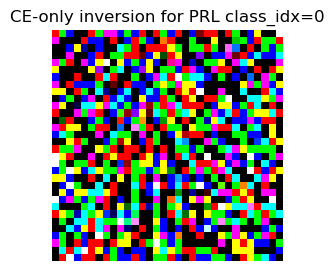

In [46]:
img0 = images[0].detach().cpu()    # (3,H,W)
plt.figure(figsize=(3, 3))
plt.imshow(img0.permute(1, 2, 0))
plt.axis("off")
plt.title(f"CE-only inversion for PRL class_idx={0}")
plt.show()

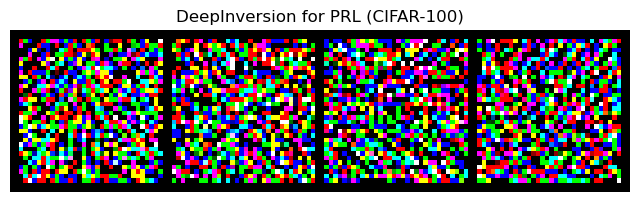

PRL 出力 index (targets): [9, 2, 6, 4, 1, 8, 9, 6, 0, 3, 4, 0, 1, 1, 4, 4, 8, 8, 1, 0, 5, 2, 0, 8, 3, 1, 7, 0, 6, 8, 3, 6, 7, 4, 2, 5, 5, 5, 8, 2, 0, 3, 8, 0, 4, 4, 6, 0, 6, 2, 5, 7, 5, 1, 3, 8, 9, 6, 2, 3, 9, 6, 6, 0, 5, 9, 0, 4, 9, 1, 4, 1, 6, 8, 6, 9, 9, 7, 9, 5, 6, 6, 5, 6, 4, 8, 0, 0, 1, 9, 6, 4, 6, 8, 0, 0, 9, 8, 6, 2, 1, 2, 7, 6, 6, 1, 9, 1, 0, 9, 9, 5, 7, 2, 0, 4, 1, 2, 8, 8, 7, 6, 9, 0, 8, 3, 4, 8]


In [45]:
show_deepinversion_batch(
    images[0:4],
    targets=targets,
    class_order=class_order,   # checkpoint から取り出した _class_order
    class_names=None,          # CIFAR100 のクラス名リストがあれば渡す
    nrow=8,
    figsize=(8, 8),
    title="DeepInversion for PRL (CIFAR-100)",
)